In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as format
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df_batter_offence = pd.read_csv('data_csv/batter_offence.csv', encoding='utf-8')
df_batter_offence2 = pd.read_csv('data_csv/batter_offence2.csv', encoding='utf-8')
df_batter_defence = pd.read_csv('data_csv/batter_defence.csv', encoding='utf-8')
df_pitcher = pd.read_csv('data_csv/pitcher.csv', encoding='utf-8')
df_team = pd.read_csv('data_csv/team.csv', encoding='utf-8')

In [ ]:
def team_avg(team):
    team_name = df_batter_offence[df_batter_offence['team'] == team].copy()
    team_name = team_name.loc[(team_name['game_cnt'] > 72)]
    team_name['avg'] = team_name['avg'].astype(float)

    year_avg_list = []
    year_list = [2022, 2023, 2024, 2025]
    for year in year_list:
        avg = team_name[team_name['year'] == year]['avg'].mean()
        year_avg_list.append(round(avg, 5))

    return year_avg_list


avg_dict = {}
for team in df_batter_offence['team'].unique():
    avg_dict[team] = team_avg(team)

avg_dict

In [ ]:
df = df_pitcher.copy().reset_index(drop=True)

for i, v in enumerate(df['inning']):
    inning = v.split()
    if len(inning) == 1:
        df.loc[i, 'inning'] = float(v)
    else:
        num, f_num = v.split()
        a, b = f_num.split('/')
        f_num = int(a) / int(b)
        result = int(num) + f_num
        df.loc[i, 'inning'] = float(result)

def team_era(team):
    over72 = df[ ( df['team'] == team ) & ( df['inning'] > 72 ) ]

    year_era_list=[]
    year_list = [2022, 2023, 2024, 2025]
    for year in year_list:
        era = over72[over72['year'] == year]['era'].mean()
        year_era_list.append(round(era, 5))

    return year_era_list

avg_era = {}
for team in df['team'].unique():
    avg_era[team] = team_era(team)

order = ['삼성', 'KIA', '두산', 'NC', 'KT', '키움', 'LG', '한화', 'SSG', '롯데']
teams_era = {team: avg_era[team] for team in order}
teams_era

In [ ]:
def team_ranks(team):
    team_ranks = []
    for year in [2022, 2023, 2024, 2025]:
        rank = df_team[(df_team['year'] == year) & (df_team['team'] == team)]['ranking'].values[0]
        team_ranks.append(rank)
    
    return team_ranks

teams_rank = {}
for team in df_team['team'].unique():
    teams_rank[team] = team_ranks(team)


order = ['삼성', 'KIA', '두산', 'NC', 'KT', '키움', 'LG', '한화', 'SSG', '롯데']
teams_rank = {team: teams_rank[team] for team in order}
teams_rank

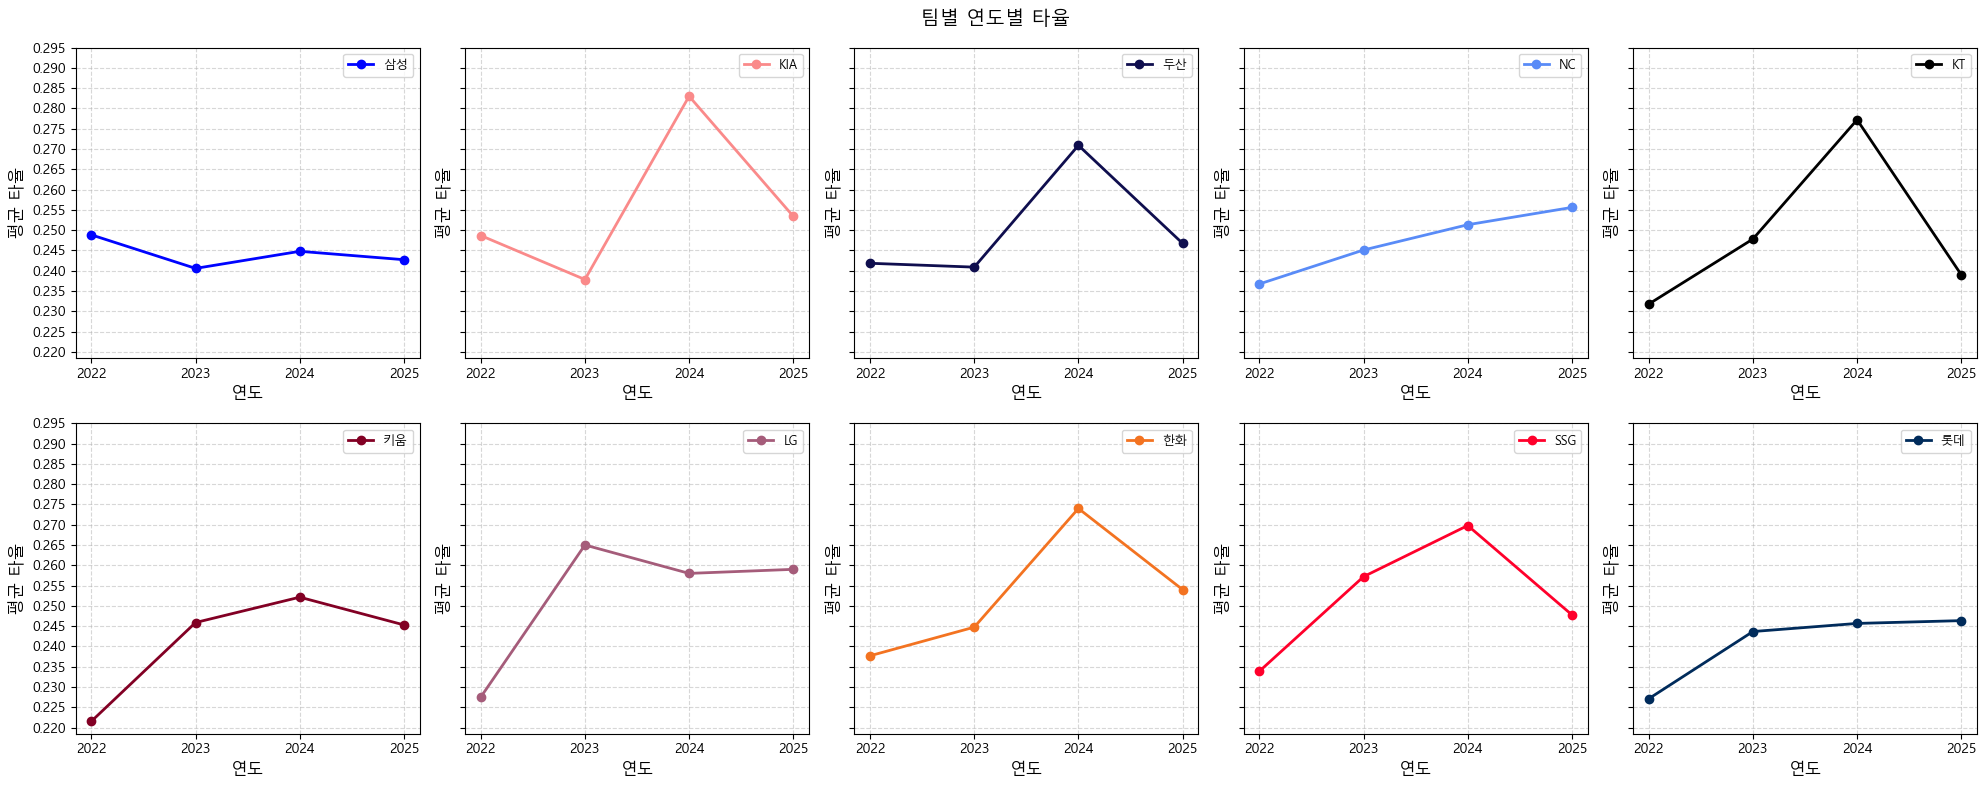

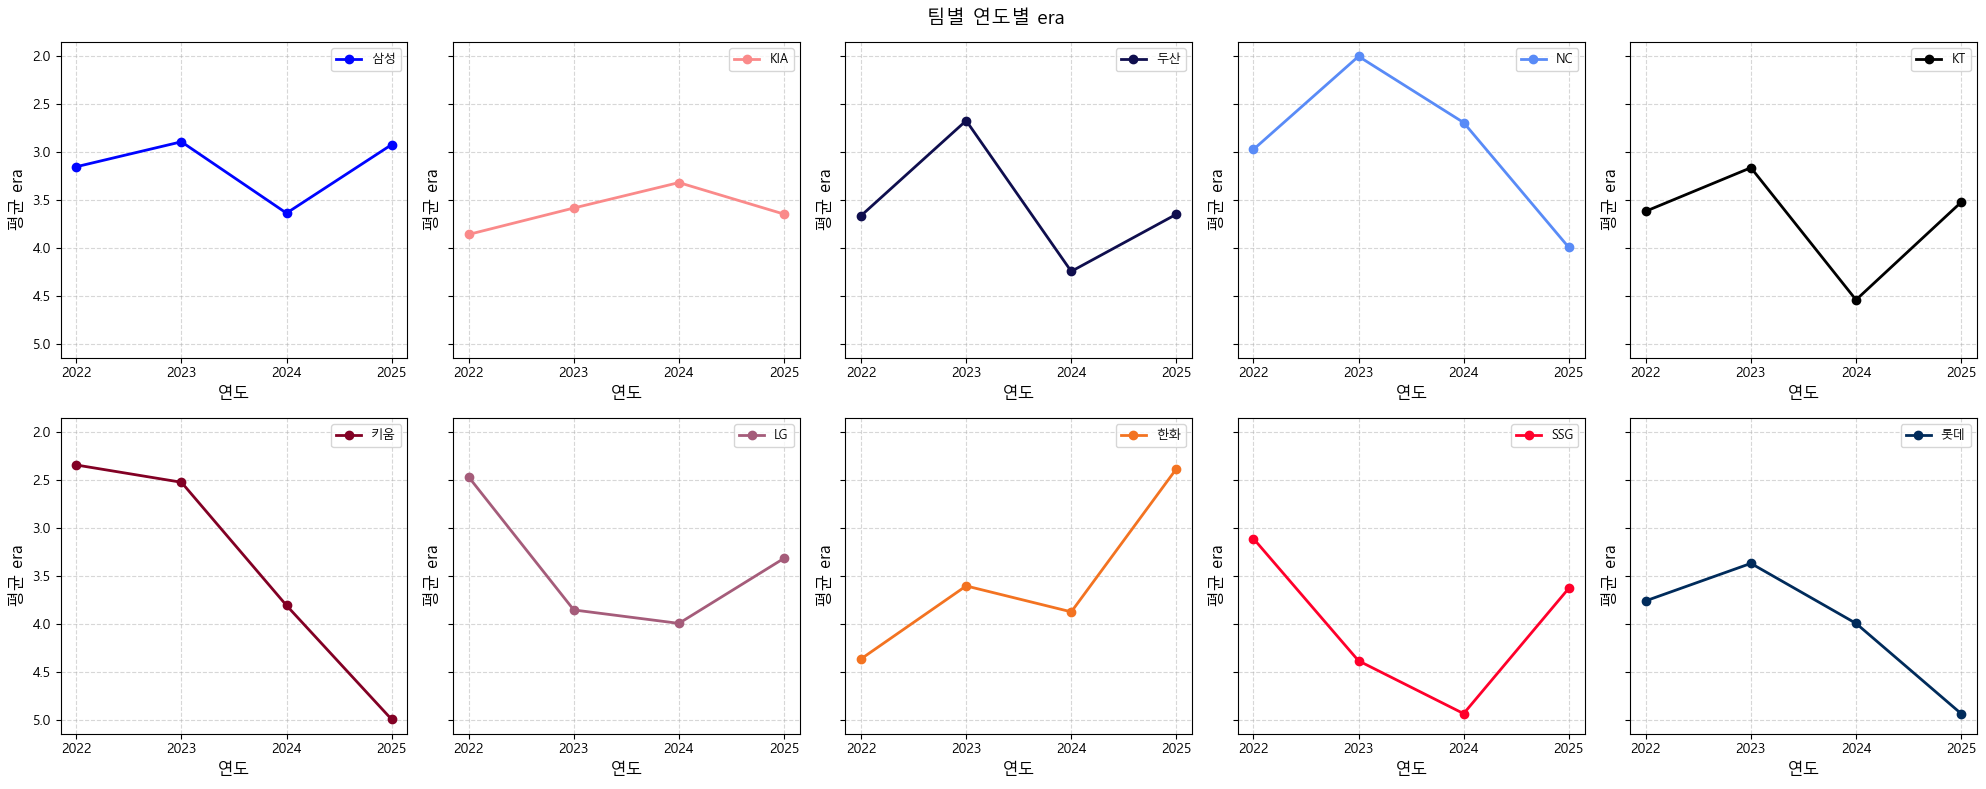

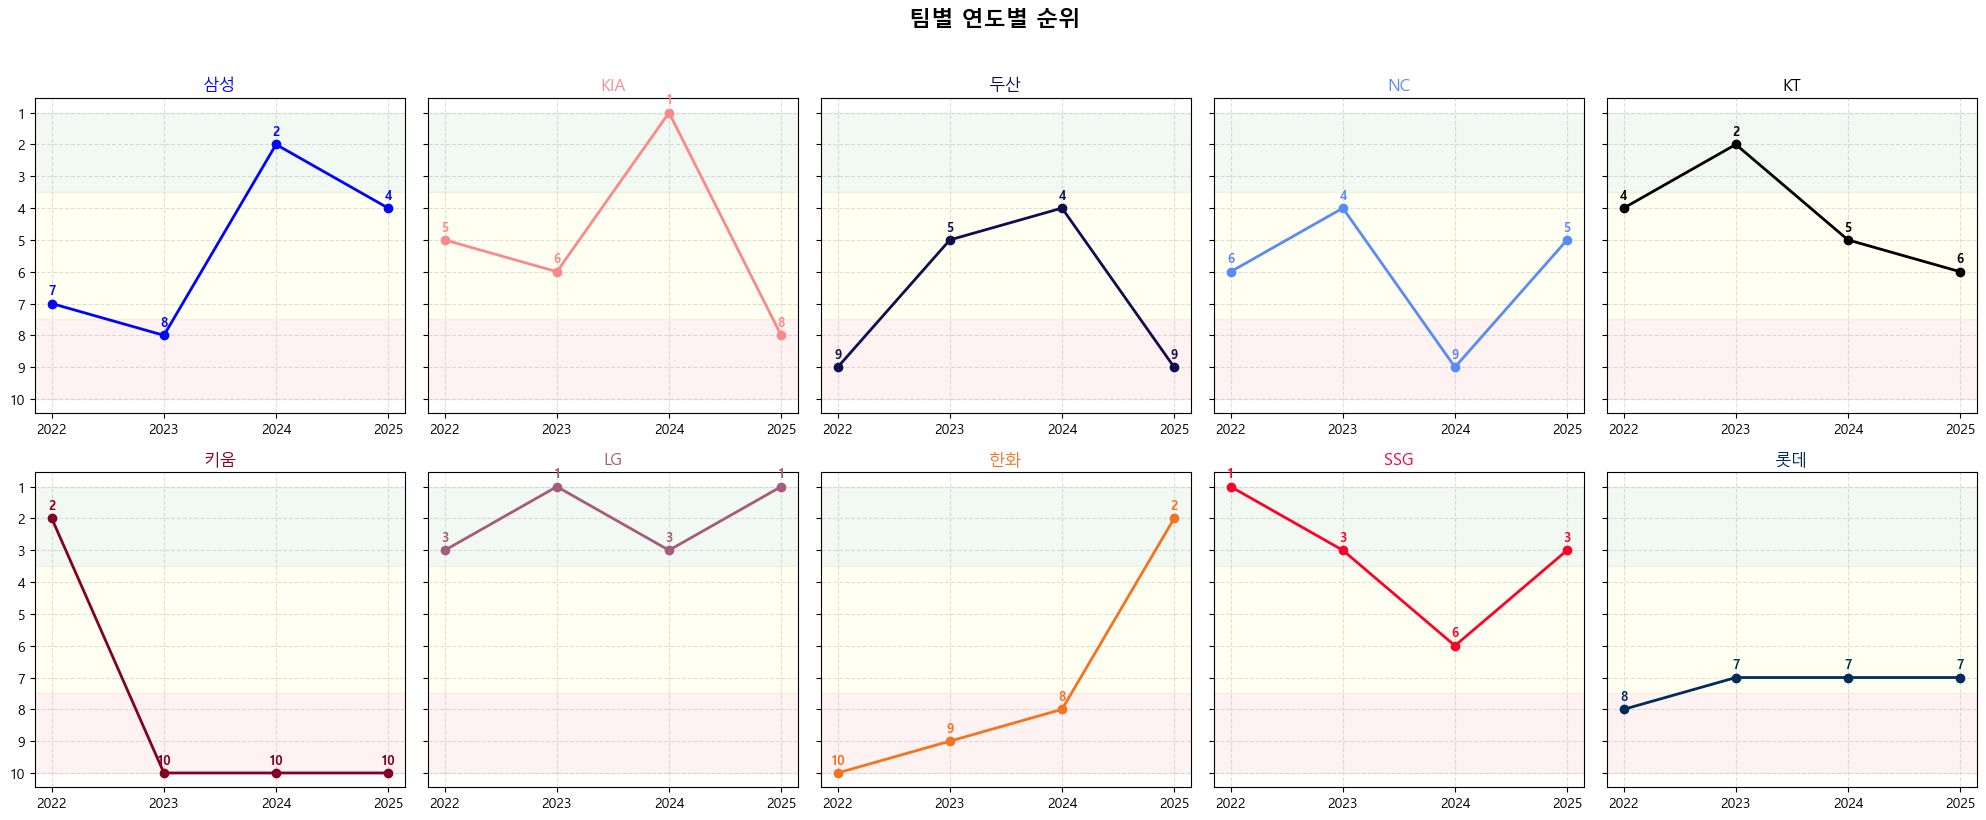

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True) # sharey : 모든 그래프가 같은 y 축 범위와 눈금 사용
axes = axes.flatten() # 2D 배열을 1D로 펼처서 순회
team_colors = {
    '삼성': "#0004FF",  
    'KIA': "#FA8A8A",   
    '두산': "#0F0E4E",  
    'NC':  "#598BF7",   
    'KT':  '#000000',  
    '키움': '#820024',  
    'LG':  "#A55C7A",   
    '한화': '#F37321', 
    'SSG': "#FF002B",   
    '롯데': '#002B5B'
}

year_list= [2022, 2023, 2024, 2025]

for idx, (team, avgs) in enumerate(avg_dict.items()):
    ax = axes[idx]

    ax.plot(year_list, avgs, marker='o', label = team, color=team_colors[team], linewidth=2, markersize=6)

    ax.set_xlabel('연도', fontsize=12)
    ax.set_ylabel('평균 타율', fontsize=12)
    ax.set_xticks(year_list)
    ax.set_yticks(np.arange(0.22, 0.30, 0.005))
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('팀별 연도별 타율', fontsize=14)
plt.tight_layout()
plt.show()

#################################################################################################################

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True) 
axes = axes.flatten()
year_list= [2022, 2023, 2024, 2025]
axes[0].invert_yaxis()
for idx, (team, era) in enumerate(teams_era.items()):
    ax = axes[idx]

    ax.plot(year_list, era, marker='o', label = team, color=team_colors[team], linewidth=2, markersize=6)
    
    ax.set_xlabel('연도', fontsize=12)
    ax.set_ylabel('평균 era', fontsize=12)
    ax.set_xticks(year_list)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('팀별 연도별 era', fontsize=14)
plt.tight_layout()
plt.show()

#################################################################################################################

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
axes = axes.flatten()

year_list = [2022, 2023, 2024, 2025]
axes[0].invert_yaxis()
for idx, (team, rank) in enumerate(teams_rank.items()):
    ax = axes[idx]
    
    # 배경 구간
    ax.axhspan(1, 3.5, alpha=0.05, color='green')
    ax.axhspan(3.5, 7.5, alpha=0.05, color='yellow')
    ax.axhspan(7.5, 10, alpha=0.05, color='red')
    
    ax.plot(year_list, rank, marker='o', color=team_colors[team], linewidth=2)


    # 순위 숫자 표시
    for x, y in zip(year_list, rank):
        ax.text(x, y - 0.2, str(y), ha='center', va='bottom', 
                fontsize=9, color=team_colors[team], fontweight='bold')
    
    ax.set_title(team, fontsize=12, color=team_colors[team])
    ax.set_xticks(year_list)
    ax.set_yticks(range(1, 11, 1))
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('팀별 연도별 순위', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

,Unnamed: 0,year,name,team,era,game_cnt,win,lose,save,hold,wpct,inning,hit,home_run,bb,hbp,kk,r,er,whip
0,0,2022,안우진,키움,2.11,30,15,8,0,0,0.652,196,131,4,55,4,224,51,46,0.95
1,1,2022,김광현,SSG,2.13,28,13,3,0,0,0.813,173 1/3,141,10,45,5,153,48,41,1.07
2,2,2022,플럿코,LG,2.39,28,15,5,0,0,0.750,162,125,13,38,2,149,53,43,1.01
3,3,2022,수아레즈,삼성,2.49,30,6,8,0,0,0.429,173 2/3,151,7,50,4,159,61,48,1.16
4,4,2022,켈리,LG,2.54,27,16,4,0,0,0.800,166 1/3,144,10,35,2,153,50,47,1.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,92,2026,사우어,KT,4.09,2,1,1,0,0,0.500,11,10,1,7,0,4,5,5,1.55
93,93,2026,화이트,SSG,5.73,2,1,0,0,0,1.000,11,15,0,6,0,8,7,7,1.91
94,94,2026,에르난데스,한화,6.30,2,1,0,0,0,1.000,10,9,0,7,0,6,7,7,1.60
95,95,2026,로드리게스,롯데,8.00,2,1,1,0,0,0.500,9,11,2,10,1,4,8,8,2.33


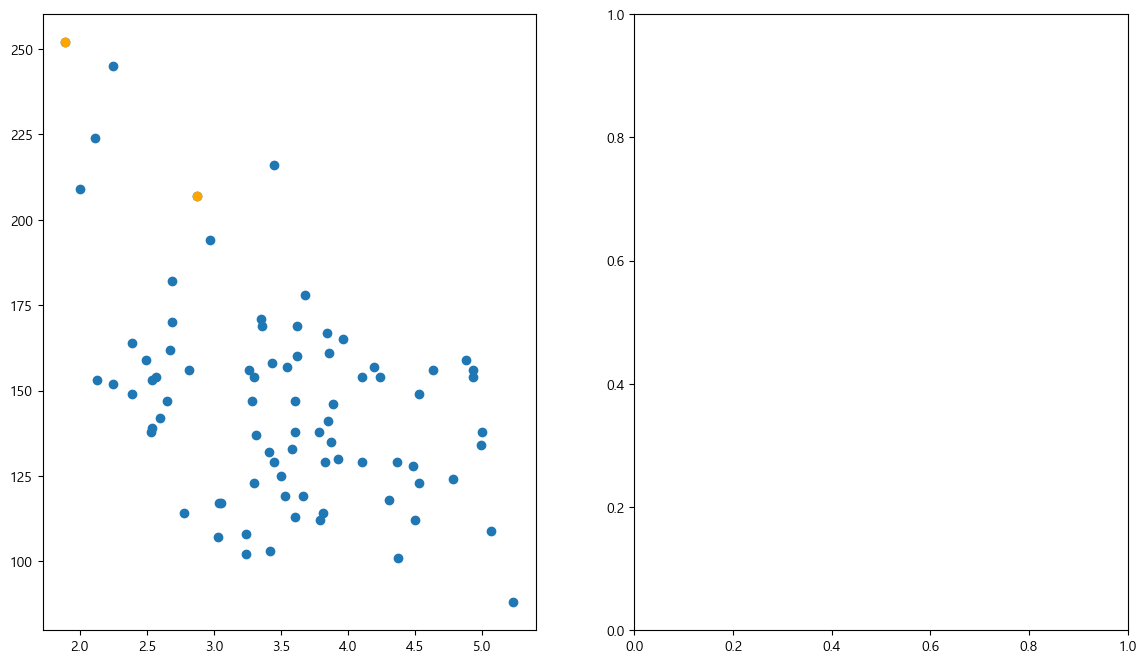

In [135]:
df = df_pitcher.copy().reset_index(drop=True)

for i, v in enumerate(df['inning']):
    inning = v.split()
    if len(inning) == 1:
        df.loc[i, 'inning'] = float(v)
    else:
        num, f_num = v.split()
        a, b = f_num.split('/')
        f_num = int(a) / int(b)
        result = int(num) + f_num
        df.loc[i, 'inning'] = float(result)

over40 = df[df['inning'] > 40]
hanhwa = over40[(over40['team'] == '한화') & (over40['year'] == 2025)]

fig, axes = plt.subplots(1, 2, figsize = (14, 8))
axes[0].scatter(over40['era'], over40['kk'])
axes[0].scatter(hanhwa['era'], hanhwa['kk'], color='orange')
df_pitcher


In [134]:
over40[(over40['team'] == '한화') & (over40['year'] == 2025)]

,Unnamed: 0,year,name,team,era,game_cnt,win,lose,save,hold,wpct,inning,hit,home_run,bb,hbp,kk,r,er,whip
59,59,2025,폰세,한화,1.89,29,17,1,0,0,0.944,180.666667,128,10,41,6,252,41,38,0.94
64,64,2025,와이스,한화,2.87,30,16,5,0,0,0.762,178.666667,127,13,56,13,207,63,57,1.02
